In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [12]:
import os
os.getcwd()

'C:\\Users\\SWARA LAKSHMI J\\PROJECT ML 1'

In [15]:
df_exp=pd.read_excel("expression_datafinal.xlsx")

In [17]:
df_exp.head()

,Gene_ID,branch12yr_SRR2080148,branch12yr_SRR2080149,branch60yr_SRR2080150,branch60yr_SRR2080151,flowers_SRR2080094,leaves_SRR2080095,roots_SRR2080096,seedlings_SRR2080097,stem12yr_SRR2080131,stem12yr_SRR2080132,stem60yr_SRR2080137,stem60yr_SRR2080138
0,Tg01g00010,0.961643,0.280474,0.334232,0.197736,0.366594,1.123209,0.494478,0.289099,0.288099,0.299413,0.230727,0.330764
1,Tg01g00020,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Tg01g00030,4.308186,4.201046,4.041839,4.142773,4.214482,3.584241,3.907987,4.445773,3.107443,2.122991,4.103011,3.757930
3,Tg01g00040,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Tg01g00050,1.806774,0.799528,0.694651,0.862790,1.236603,2.522460,2.003293,1.373359,0.883783,0.869362,0.888663,0.597340


In [18]:
df_gene=pd.read_excel("gene_listfinal.xlsx")

In [19]:
df_gene.head()

,seqid,source,type,start,end,score,strand,phase,attributes,Gene_ID,Gene_Name,length
0,Pseudomolecule_05,teak_v1,gene,9107298,9120921,.,+,.,ID=Tg05g11190;Name=Tg05g11190,Tg05g11190,Tg05g11190,13624
1,Pseudomolecule_05,teak_v1,gene,9126711,9133302,.,+,.,ID=Tg05g11200;Name=Tg05g11200,Tg05g11200,Tg05g11200,6592
2,Pseudomolecule_05,teak_v1,gene,9140962,9145231,.,+,.,ID=Tg05g11210;Name=Tg05g11210,Tg05g11210,Tg05g11210,4270
3,Pseudomolecule_05,teak_v1,gene,9150767,9151678,.,-,.,ID=Tg05g11220;Name=Tg05g11220,Tg05g11220,Tg05g11220,912
4,Pseudomolecule_05,teak_v1,gene,9158060,9158823,.,+,.,ID=Tg05g11230;Name=Tg05g11230,Tg05g11230,Tg05g11230,764


In [20]:
df_meta=pd.read_excel("metadatafinal.xlsx")

In [21]:
df_meta.head()

,Unnamed: 0,Run_ID (SRR),BioSample_ID (SAMN),Age,Read_Length,Total_Reads,Total_Bases,Institution,Developmental_Stage,Experiment_ID (SRX),...,2015-07-05 00:00:00,2015-06-2623:48:00Z,Flowers,Flowers.1,hermaphrodite,Unnamed: 15,ILLUMINA,SAMN03784589,Unnamed: 18,Unnamed: 19
0,0,2,SRR2080095,SAMN03784590,3-month,202,3.63 G,2.42 Gb,UNIVERSITY OF SAO PAULO - LUIZ DE QUEIROZ COLLEGE,Young plants,...,2015-07-05,2015-06-2623:43:00Z,Leaves,Leaves,NaN,NaN,ILLUMINA,SAMN03784590,NaN,NaN
1,1,3,SRR2080096,SAMN03784593,3-month,202,3.28 G,2.20 Gb,UNIVERSITY OF SAO PAULO - LUIZ DE QUEIROZ COLLEGE,Young plants,...,2015-07-05,2015-06-2623:42:00Z,Roots,Roots,hermaphrodite,NaN,ILLUMINA,SAMN03784593,NaN,NaN
2,2,4,SRR2080097,SAMN03784594,2 weeks,202,3.81 G,2.56 Gb,UNIVERSITY OF SAO PAULO - LUIZ DE QUEIROZ COLLEGE,Seedling,...,2015-07-05,2015-06-2623:47:00Z,Seedlings,Seedling (entire plants),hermaphrodite,NaN,ILLUMINA,SAMN03784594,NaN,Germination on Murashige & Skoog medium
3,3,5,SRR2080098,SAMN03784591,12 and 60-yr-old,200,14.42 G,9.68 Gb,UNIVERSITY OF SAO PAULO - LUIZ DE QUEIROZ COLLEGE,Adult,...,2015-11-04,2015-10-3018:12:00Z,Stem Secondary Xylem,Secondary xylem from stem,hermaphrodite,NaN,ILLUMINA,SAMN03784591,NaN,NaN
4,4,6,SRR2080099,SAMN03784592,12 and 60-yr-old,201,13.51 G,8.95 Gb,UNIVERSITY OF SAO PAULO - LUIZ DE QUEIROZ COLLEGE,Adult,...,2016-02-12,2016-02-0715:37:00Z,Branch Secondary Xylem,Secondary xylem from branches,hermaphrodite,NaN,ILLUMINA,SAMN03784592,NaN,NaN


In [23]:

# 2. Link Expression Samples to Metadata Labels
# We extract the SRR ID from column names like 'branch12yr_SRR2080148'
sample_info = []
for col in df_exp.columns[1:]:
    srr_id = col.split('_')[-1]
    # Find this SRR in the metadata (it appears to be in the BioSample column in your file)
    match = df_meta[df_meta.apply(lambda row: row.astype(str).str.contains(srr_id).any(), axis=1)]
    
    if not match.empty:
        tissue = match.iloc[0]['Flowers'] # The 'Flowers' column contains tissue types
        stage = match.iloc[0]['Developmental_Stage']
        sample_info.append({'SampleID': col, 'SRR': srr_id, 'Tissue': tissue, 'Stage': stage})
    else:
        sample_info.append({'SampleID': col, 'SRR': srr_id, 'Tissue': 'Unknown', 'Stage': 'Unknown'})

metadata_map = pd.DataFrame(sample_info)
print("Data loaded and samples matched to metadata successfully.")

Data loaded and samples matched to metadata successfully.


# BOXPLOT OF EXPRESSION GENES TO CHECK NORMALIZATION IN LOG

C:\Users\SWARA LAKSHMI J\AppData\Local\Temp\ipykernel_8172\3156803464.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x='Sample', y='Expr', ax=axes[0,0], palette='Set3')


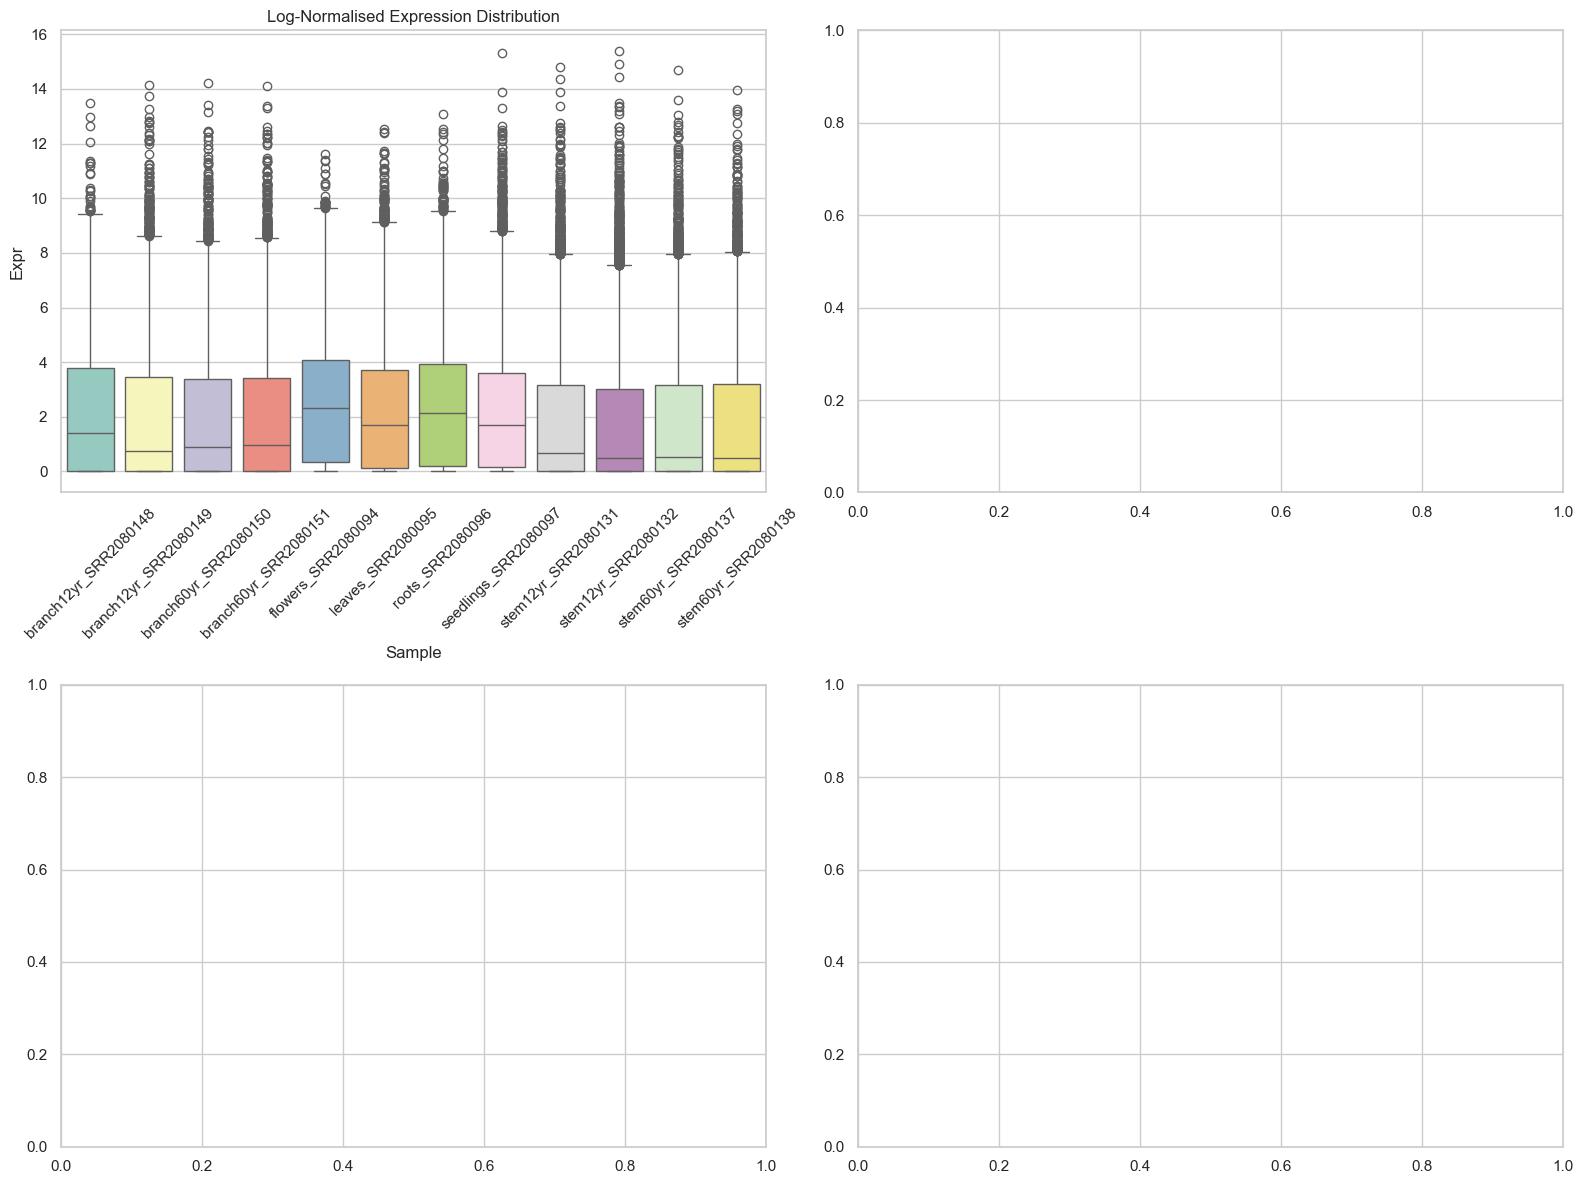

In [46]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Boxplot of Expression (Check Normalization)
melted = df_exp.melt(id_vars='Gene_ID', var_name='Sample', value_name='Expr')
sns.boxplot(data=melted, x='Sample', y='Expr', ax=axes[0,0], palette='Set3')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_title('Log-Normalised Expression Distribution')


plt.tight_layout()
plt.savefig('eda_dashboardboxplot1.png', dpi=300) # Saves the 4-way dashboard
plt.show()


# HEATMAP 

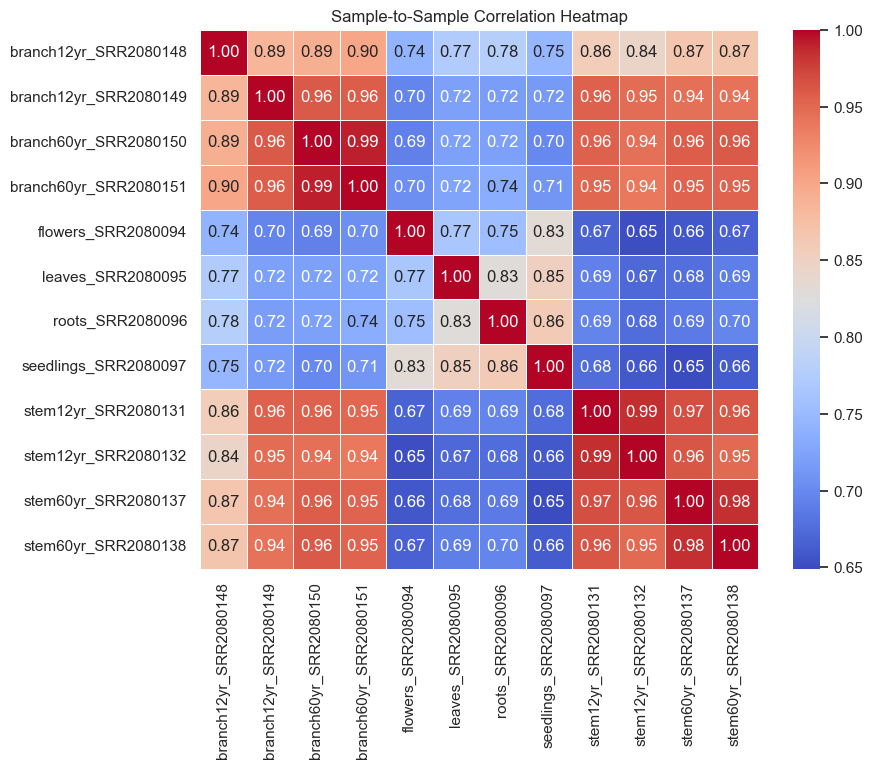

In [39]:
plt.figure(figsize=(9,7))
# Calculate Pearson correlation
corr = df_exp.iloc[:, 1:].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Sample-to-Sample Correlation Heatmap')

# Save the image
plt.savefig('2_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

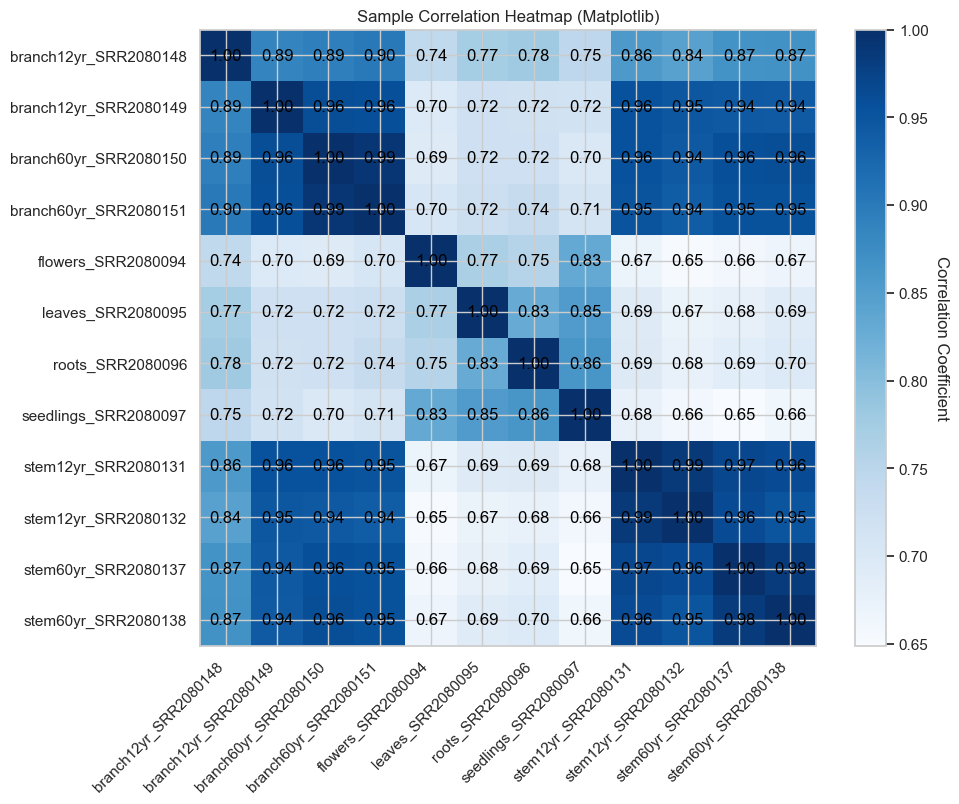

In [58]:

import numpy as np
# 2. Calculate the correlation matrix
# We exclude the 'Gene_ID' column to correlate only numeric sample data
corr = df_exp.iloc[:, 1:].corr()

# 3. Create the Heatmap
plt.figure(figsize=(10, 8))
# 'imshow' displays the data as an image; 'cmap' defines the colors (coolwarm is standard)
im = plt.imshow(corr, cmap='Blues', interpolation='nearest')

# 4. Add a Colorbar to show the scale
cbar = plt.colorbar(im)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=15)

# 5. Add Labels
# Set the tick positions
ticks = np.arange(len(corr.columns))
plt.xticks(ticks, corr.columns, rotation=45, ha='right')
plt.yticks(ticks, corr.columns)

# 6. Add Text Annotations (Optional: showing the numbers inside the boxes)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', 
                 ha='center', va='center', color='black')

plt.title('Sample Correlation Heatmap (Matplotlib)')

# 7. Save the image separately
plt.savefig('heatmap_matplotlib.png', dpi=300, bbox_inches='tight')
plt.show()

# HISTOGRAM 

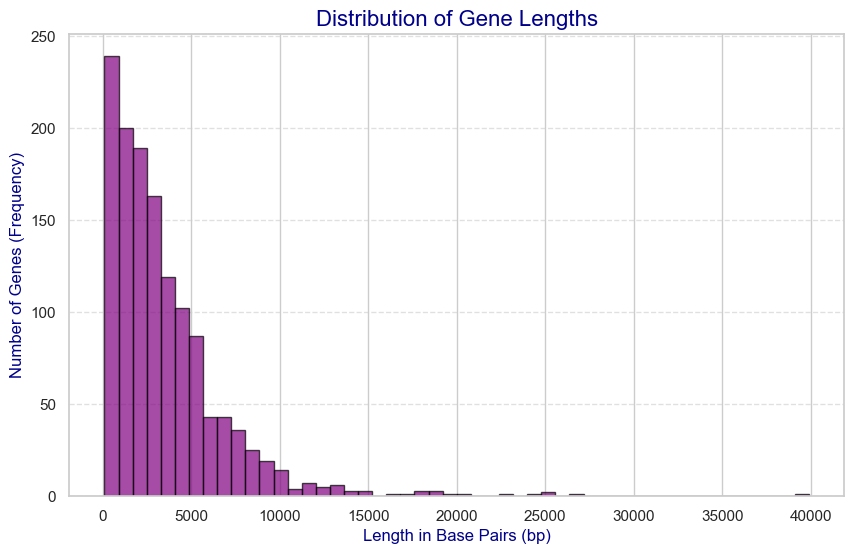

In [53]:
plt.figure(figsize=(10, 6))

# plt.hist parameters:
# bins=50: divides the data into 50 bars
# color: the fill color of the bars
# edgecolor: the line color around the bars (makes it look cleaner)
# alpha: transparency (0.7 makes it slightly see-through)
plt.hist(df_gene['length'], bins=50, color='purple', edgecolor='black', alpha=0.7)

# 3. Add Labels and Styling
plt.title('Distribution of Gene Lengths', fontsize=16,color='darkblue')
plt.xlabel('Length in Base Pairs (bp)', fontsize=12,color='darkblue')
plt.ylabel('Number of Genes (Frequency)', fontsize=12,color='darkblue')

# 4. Add a grid
# This makes it easier to see the exact counts on the Y-axis
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 5. Save the image separately
plt.savefig('histogram_matplotlib.png', dpi=300, bbox_inches='tight')

# 6. Display the plot
plt.show()

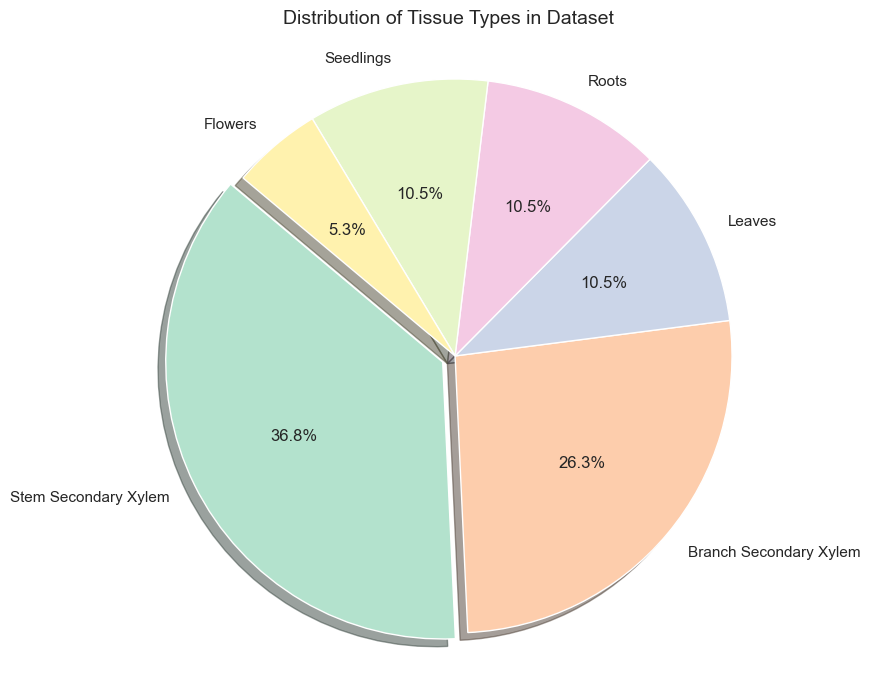

In [61]:
# 2. Prepare the data (Count occurrences of each tissue)
tissue_counts = df_meta['Flowers'].value_counts()
labels = tissue_counts.index
sizes = tissue_counts.values

# 3. Create the Pie Chart
plt.figure(figsize=(10, 8))

# Define colors (optional)
colors = plt.get_cmap('Pastel2').colors

# plt.pie parameters:
# labels: the names of the tissues
# autopct: formats the percentages (1.1f%% means one decimal place)
# startangle: rotates the start of the chart (140 is a common aesthetic choice)
# explode: pulls out the first slice slightly (highlighting the largest category)
explode_values = [0.05] + [0] * (len(labels) - 1) 

plt.pie(sizes, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=explode_values, 
        shadow=True)

# 4. Styling
plt.title('Distribution of Tissue Types in Dataset', fontsize=14, pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# 5. Save the image separately
plt.savefig('pie_chart_matplotlib.png', dpi=300, bbox_inches='tight')

# 6. Display
plt.show()

# PIE CHART TISSUE TYPE DISTRIBUTION

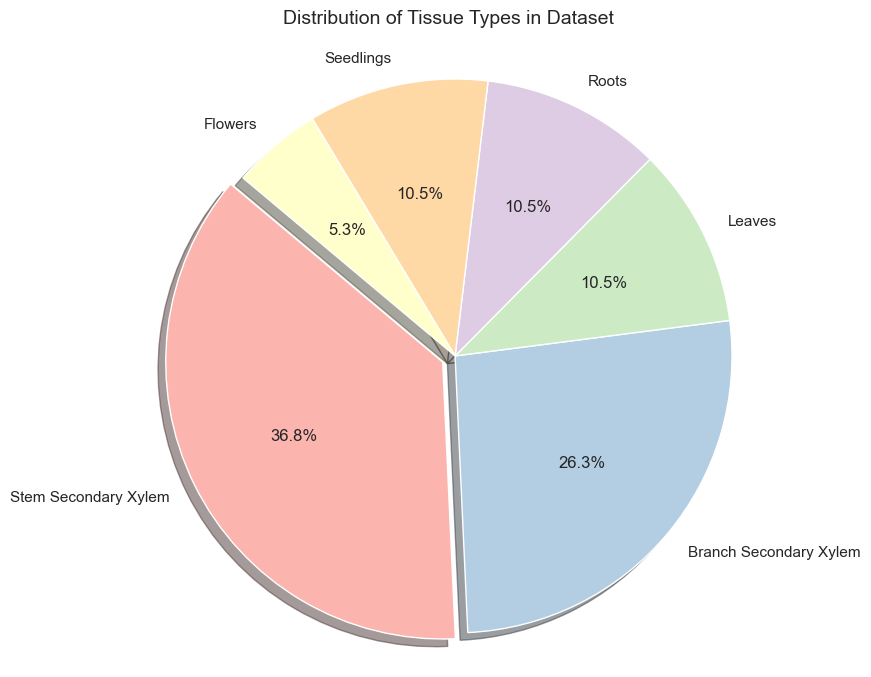

In [65]:

# 2. Prepare the data (Count occurrences of each tissue)
tissue_counts = df_meta['Flowers'].value_counts()
labels = tissue_counts.index
sizes = tissue_counts.values

# 3. Create the Pie Chart
plt.figure(figsize=(10, 8))

# Define colors (optional)
colors = plt.get_cmap('Pastel1').colors

# plt.pie parameters:
# labels: the names of the tissues
# autopct: formats the percentages (1.1f%% means one decimal place)
# startangle: rotates the start of the chart (140 is a common aesthetic choice)
# explode: pulls out the first slice slightly (highlighting the largest category)
explode_values = [0.05] + [0] * (len(labels) - 1) 

plt.pie(sizes, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=explode_values, 
        shadow=True)

# 4. Styling
plt.title('Distribution of Tissue Types in Dataset', fontsize=14, pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# 5. Save the image separately
plt.savefig('pie_chart_matplotlib.png', dpi=300, bbox_inches='tight')

# 6. Display
plt.show()

In [82]:
if X.shape[0]>0:
    pca.fit(X)
else:
    print("Warning input data empty")

In [84]:
print(f"Original shape:{df_exp.shape}")

Original shape:(35844, 12)


In [88]:
# Returns a list of column names where all values are 0
zero_cols = df_exp.columns[(df_exp == 0).all()]

print("Columns with all zeros:", list(zero_cols))

Columns with all zeros: []


In [89]:
# Returns columns that are entirely empty
empty_cols = df_exp.columns[df_exp.isnull().all()]

print("Columns that are entirely empty (NaN):", list(empty_cols))

Columns that are entirely empty (NaN): []


Saved: pca_plot.png and pca_plot.pdf


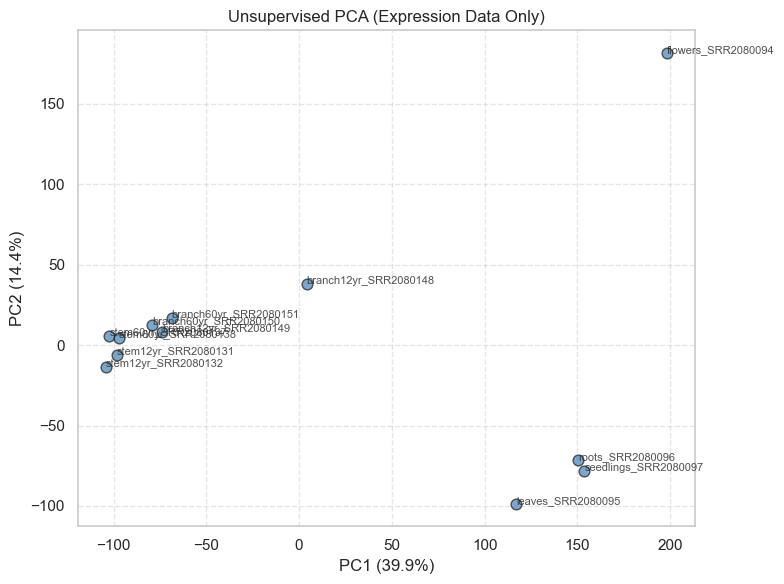

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the data
df_exp = pd.read_excel("expression_datafinal.xlsx", index_col=0)

# 2. Transpose (Samples must be Rows)
X = df_exp.T 

# 3. Scale the data
X_scaled = StandardScaler().fit_transform(X)

# 4. Run PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_ * 100

# 5. Plotting
plt.figure(figsize=(8, 6))

# Plot all points as one color since we have no metadata
plt.scatter(pca_features[:, 0], pca_features[:, 1], c='steelblue', s=60, edgecolors='k', alpha=0.7)

# Add Sample IDs as text labels so you know which dot is which
for i, sample_id in enumerate(X.index):
    plt.annotate(sample_id, (pca_features[i, 0], pca_features[i, 1]), fontsize=8, alpha=0.8)

plt.xlabel(f'PC1 ({var_exp[0]:.1f}%)')
plt.ylabel(f'PC2 ({var_exp[1]:.1f}%)')
plt.title('Unsupervised PCA (Expression Data Only)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("pca_plot.png", dpi=300, bbox_inches='tight')
plt.savefig("pca_plot.pdf") # Also saving as PDF for better scaling
print("Saved: pca_plot.png and pca_plot.pdf")
plt.show()